In [1]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
import spacy
from tqdm.auto import tqdm
from gensim.models import LdaModel, CoherenceModel, Phrases
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
save_path_csv = "/content/drive/MyDrive/nlp/final project/clean_base_dataset.csv"

df = pd.read_csv(save_path_csv)

print("Loaded:", save_path_csv)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())

Loaded: /content/drive/MyDrive/nlp/final project/clean_base_dataset.csv
Shape: (196276, 6)


,url,date,title,clean_text,text_len,domain
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",3501,blockworks.co
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,This AI video of gymnastics might be the freak...,5585,boingboing.net
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","If using AI feels like a chore, try this - Boi...",5880,boingboing.net
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation Mode...,4072,citylife.capetown
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers wit...,4347,citylife.capetown



Columns: ['url', 'date', 'title', 'clean_text', 'text_len', 'domain']


In [5]:
!pip -q install spacy
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**Creating a sample**

In [6]:
df_model = df.sample(40000, random_state=42).copy()

texts = df_model["clean_text"].fillna("").astype(str).tolist()

print("Number of documents:", len(texts))

Number of documents: 40000


**LDA Approach**

In [7]:
# basic cleaning: lowercase + remove urls/emails + keep letters/spaces
def basic_clean_for_lda(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def clean_text_spacy_lda(corpus, n_process=1, batch_size=200, max_chars=4000):
    """
    LDA-friendly tokenization:
    - truncate long docs for stability
    - remove stopwords
    - keep NOUN/VERB/ADJ
    - lemmatize + lowercase
    """
    corpus = [basic_clean_for_lda(t)[:max_chars] for t in corpus]
    tokenized = []

    for doc in tqdm(nlp.pipe(corpus, n_process=n_process, batch_size=batch_size),
                    total=len(corpus)):
        tokens = [
            tok.lemma_
            for tok in doc
            if tok.is_alpha
            and not tok.is_stop
            and len(tok) > 2
            and tok.pos_ in ("NOUN", "VERB", "ADJ")
        ]
        tokenized.append(tokens)

    return tokenized

texts = df_model["clean_text"].tolist()
normalized_corpus = clean_text_spacy_lda(texts, n_process=1, batch_size=200, max_chars=4000)

print("Cleaned docs:", len(normalized_corpus))
print("Example tokens:", normalized_corpus[0][:30])

  0%|          | 0/40000 [00:00<?, ?it/s]

Cleaned docs: 40000
Example tokens: ['add', 'tech', 'drive', 'ordering', 'test', 'orlandowe', 'love', 'floridacontest', 'watch', 'live', 'expand', 'collapse', 'search', 'search', 'site', 'news', 'headlinescentral', 'headlinesnational', 'countylake', 'politicslivenow', 'weathercentral', 'true', 'crime', 'drone', 'sundayweather', 'center', 'live', 'weather', 'stop', 'forecasthour']


In [8]:
bigram_model = Phrases(
    normalized_corpus,
    min_count=20,     # larger dataset -> raise min_count
    threshold=15
)

for i in range(len(normalized_corpus)):
    for phrase in bigram_model[normalized_corpus[i]]:
        if "_" in phrase:
            normalized_corpus[i].append(phrase)

print("Example WITH bigrams:", normalized_corpus[0][:40])

Example WITH bigrams: ['add', 'tech', 'drive', 'ordering', 'test', 'orlandowe', 'love', 'floridacontest', 'watch', 'live', 'expand', 'collapse', 'search', 'search', 'site', 'news', 'headlinescentral', 'headlinesnational', 'countylake', 'politicslivenow', 'weathercentral', 'true', 'crime', 'drone', 'sundayweather', 'center', 'live', 'weather', 'stop', 'forecasthour', 'hour', 'day', 'forecasttheme', 'park', 'forecastuv', 'indexbeach', 'weatherfox', 'thunder', 'truckstorm', 'team']


In [9]:
dictionary = Dictionary(normalized_corpus)
print("Dictionary size BEFORE:", len(dictionary))

dictionary.filter_extremes(
    no_below=int(0.01 * len(normalized_corpus)),  # appears in >= 1% docs
    no_above=0.5                                  # appears in <= 50% docs
)

print("Dictionary size AFTER:", len(dictionary))

corpus_bow = [dictionary.doc2bow(doc) for doc in normalized_corpus]

print("Docs:", len(corpus_bow))
print("Vocab:", len(dictionary))
print("Example BOW:", corpus_bow[0][:10])

Dictionary size BEFORE: 203168
Dictionary size AFTER: 2985
Docs: 40000
Vocab: 2985
Example BOW: [(0, 1), (1, 4), (2, 3), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 1), (9, 1)]



Training LDA with k=6...
  coherence=0.5447

Training LDA with k=8...
  coherence=0.5367

Training LDA with k=10...
  coherence=0.5476

Training LDA with k=12...
  coherence=0.5693

Training LDA with k=15...
  coherence=0.5623

Training LDA with k=18...
  coherence=0.5692

Training LDA with k=20...
  coherence=0.5868


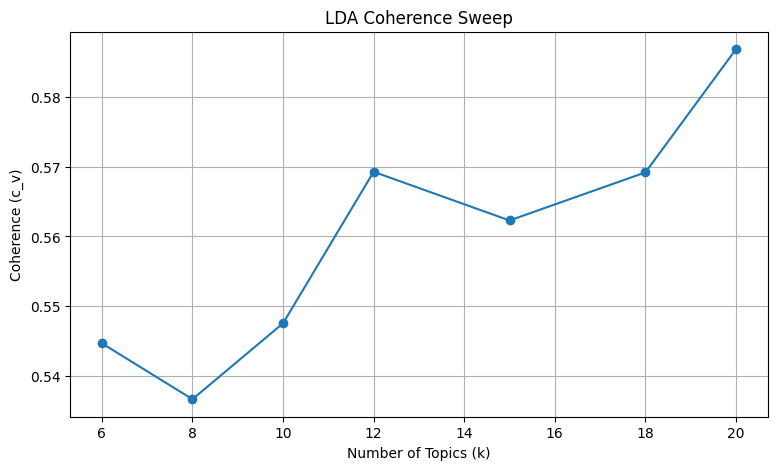

Best k by coherence: 20  (score=0.5868)


In [10]:
topic_nums = [6, 8, 10, 12, 15, 18, 20]
coherence_scores = []

for k in topic_nums:
    print(f"\nTraining LDA with k={k}...")
    lda_tmp = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=8,
        alpha="auto",
        eta="auto",
        per_word_topics=False
    )

    cm = CoherenceModel(
        model=lda_tmp,
        texts=normalized_corpus,
        dictionary=dictionary,
        coherence="c_v"
    )
    coh = cm.get_coherence()
    coherence_scores.append(coh)
    print(f"  coherence={coh:.4f}")

plt.figure(figsize=(9,5))
plt.plot(topic_nums, coherence_scores, marker="o")
plt.xlabel("Number of Topics (k)")
plt.ylabel("Coherence (c_v)")
plt.title("LDA Coherence Sweep")
plt.grid(True)
plt.show()

best_k = topic_nums[int(coherence_scores.index(max(coherence_scores)))]
print(f"Best k by coherence: {best_k}  (score={max(coherence_scores):.4f})")

In [11]:
optimal_num_topics = best_k

lda_final = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=optimal_num_topics,
    random_state=42,
    passes=10,
    alpha="auto",
    eta="auto",
    per_word_topics=True
)

print("Trained final LDA with k =", optimal_num_topics)

Trained final LDA with k = 20


In [12]:
import numpy as np

def top_docs_for_topic_gensim(model, corpus_bow, topic_id, topn=3):
    """Return (doc_index, topic_probability) for top docs in a topic."""
    scored = []
    for i, bow in enumerate(corpus_bow):
        topic_probs = dict(model.get_document_topics(bow, minimum_probability=0))
        scored.append((i, topic_probs.get(topic_id, 0.0)))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:topn]

lda_rows = []

for topic_id in range(optimal_num_topics):
    # top words
    top_words = [w for w, _ in lda_final.show_topic(topic_id, topn=12)]

    # top docs for this topic
    top_docs = top_docs_for_topic_gensim(lda_final, corpus_bow, topic_id, topn=3)

    examples = []
    probs = []
    for doc_idx, p in top_docs:
        snippet = str(df_model.iloc[doc_idx]["clean_text"])[:320].replace("\n", " ")
        examples.append(snippet + "...")
        probs.append(p)

    lda_rows.append({
        "topic_id": topic_id,
        "top_words": ", ".join(top_words),
        "avg_topdoc_prob": round(float(np.mean(probs)), 3),
        "example_snippets": " | ".join(examples)
    })

lda_table = pd.DataFrame(lda_rows).sort_values("topic_id")
lda_table

,topic_id,top_words,avg_topdoc_prob,example_snippets
0,0,"health, patient, care, medical, healthcare, ca...",0.936,ScreenPoint Medical Showcases Transpara® AI Br...
1,1,"newswire, distribution, country, industry, int...",0.993,Artificial Intelligence in Healthcare Market S...
2,2,"radio, schedule, program, public, music, air, ...",0.997,Artificial Intelligence helped connect a Holoc...
3,3,"market, share, stock, report, chip, growth, ye...",0.995,"NBC Securities Inc. Has $409,000 Holdings in F..."
4,4,"user, model, tool, feature, content, video, ag...",0.988,"MNDXT - Chat, write, design your AI companion ..."
5,5,"price, market, trade, day, trading, crypto, ch...",0.996,BAD to SCR: Convert Bad Idea AI to Seychelles ...
6,6,"business, service, electronic, computer, trans...",0.998,Transforming Healthcare: AI in Diagnostics Mar...
7,7,"datum, machine, model, system, human, learning...",0.996,តើ AI ជិតដល់កម្រិតណាក្នុងការក្លាយជាមនុស្ស? រំល...
8,8,"job, datum, global, student, year, science, ed...",0.995,"Data Scientist Salary in Delhi, IndiaFor Emplo..."
9,9,"market, solution, search, insight, feature, in...",0.996,Buy This Top Artificial Intelligence (AI) Stoc...


In [13]:
# Assign dominant topic to each document


dominant_topics = []
dominant_probs = []

for bow in corpus_bow:
    topic_id, prob = max(lda_final.get_document_topics(bow), key=lambda x: x[1])
    dominant_topics.append(topic_id)
    dominant_probs.append(prob)

df_model["dominant_topic"] = dominant_topics
df_model["dominant_prob"] = dominant_probs

# Compute topic size + share

topic_counts = df_model["dominant_topic"].value_counts().sort_index()
topic_share = (topic_counts / len(df_model)).round(4)

lda_table["doc_count"] = lda_table["topic_id"].map(topic_counts).fillna(0).astype(int)
lda_table["doc_share"] = lda_table["topic_id"].map(topic_share).fillna(0)

print("\n=== Topic Sizes ===")
display(
    lda_table[["topic_id", "doc_count", "doc_share", "top_words"]]
    .sort_values("doc_count", ascending=False)
)


# Add manual topic labels (EDIT THESE after inspection)

topic_labels = {
    0: "Healthcare & Clinical AI",
    1: "Newswire / Distribution (noise)",
    2: "Broadcast / Radio / Programming (noise)",
    3: "AI Chips & Financial Markets",
    4: "AI Tools & Applications",
    5: "Crypto & AI Trading",
    6: "Enterprise IT & Digital Transformation",
    7: "Non-English / Mixed (noise)",
    8: "Jobs & Data Science Workforce",
    9: "AI Investment Content",
    10: "Education & Opinion",
    11: "Consumer Tech & Devices",
    12: "Entertainment / Media (noise)",
    13: "Cloud Platforms & Enterprise Solutions",
    14: "Generative AI Images & Creative Tools",
    15: "Finance & Investment",
    16: "ChatGPT & AI Assistants",
    17: "OpenAI & Big Tech AI Industry",
    18: "Local News / Weather (noise)",
    19: "Cybersecurity & AI Risk"
}

lda_table["label"] = lda_table["topic_id"].map(topic_labels)

# Remove noise topics (adjust if needed)

noise_topics = {1, 2, 7, 12, 18}

df_focus = df_model[~df_model["dominant_topic"].isin(noise_topics)].copy()

print("\nDocs before filtering:", len(df_model))
print("Docs after removing noise:", len(df_focus))

# Extract company names (ORG) from TITLES (fast method)

import spacy
from collections import Counter

nlp_ner = spacy.load("en_core_web_sm")

def extract_orgs(text):
    doc = nlp_ner(str(text))
    return [ent.text for ent in doc.ents if ent.label_ == "ORG"]

df_focus["orgs"] = df_focus["title"].apply(extract_orgs)


# Get top companies per topic

top_companies_by_topic = {}

for t in sorted(df_focus["dominant_topic"].unique()):
    orgs = [
        org
        for org_list in df_focus[df_focus["dominant_topic"] == t]["orgs"]
        for org in org_list
    ]
    top_companies_by_topic[t] = Counter(orgs).most_common(15)


# Convert to DataFrame
rows = []
for t, orgs in top_companies_by_topic.items():
    for org, count in orgs:
        rows.append({
            "topic_id": t,
            "label": topic_labels.get(t, ""),
            "company": org,
            "mention_count": count
        })

company_table = pd.DataFrame(rows).sort_values(
    ["topic_id", "mention_count"], ascending=[True, False]
)

print("\n Top Companies by Topic ")
display(company_table.head(30))


=== Topic Sizes ===


,topic_id,doc_count,doc_share,top_words
13,13,5452,0.1363,"customer, solution, platform, business, servic..."
17,17,3948,0.0987,"say, openai, artificial_intelligence, tech, mo..."
12,12,3245,0.0811,"video, say, year, world, game, medium, image, ..."
16,16,2861,0.0715,"chatgpt, search, say, use, chatbot, help, work..."
7,7,2561,0.0640,"datum, machine, model, system, human, learning..."
3,3,2505,0.0626,"market, share, stock, report, chip, growth, ye..."
4,4,2415,0.0604,"user, model, tool, feature, content, video, ag..."
18,18,1874,0.0468,"weather, video, local, search, sport, hour, st..."
8,8,1803,0.0451,"job, datum, global, student, year, science, ed..."
10,10,1714,0.0428,"sport, business, subscribe, health, opinion, e..."



Docs before filtering: 40000
Docs after removing noise: 29886

 Top Companies by Topic 


,topic_id,label,company,mention_count
0,0,Healthcare & Clinical AI,AI,50
1,0,Healthcare & Clinical AI,SafetyLit,25
2,0,Healthcare & Clinical AI,Eureka Clinical AI Platform,13
3,0,Healthcare & Clinical AI,TeraRecon,10
4,0,Healthcare & Clinical AI,Healthcare,9
5,0,Healthcare & Clinical AI,ScienceDaily,8
6,0,Healthcare & Clinical AI,ExBulletin,8
7,0,Healthcare & Clinical AI,Aidoc,7
8,0,Healthcare & Clinical AI,AI Solution for Pulmonary Embolism Clinically ...,7
9,0,Healthcare & Clinical AI,Improves Patient Access to Treatment,7


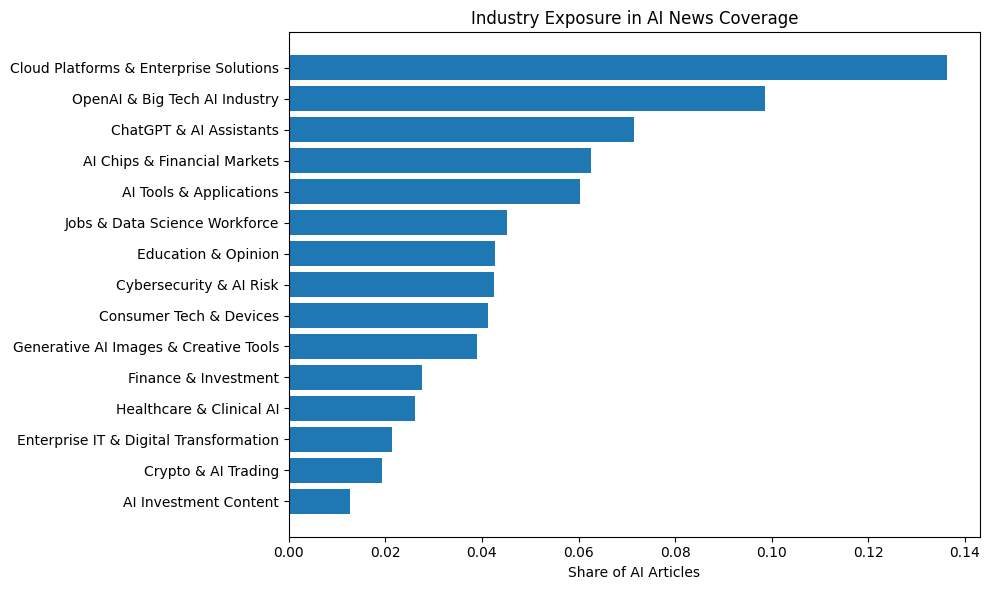

In [14]:
import matplotlib.pyplot as plt

# Keep only non-noise topics
plot_df = lda_table[~lda_table["topic_id"].isin({1,2,7,12,18})].copy()

plot_df = plot_df.sort_values("doc_share", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(plot_df["label"], plot_df["doc_share"])
plt.xlabel("Share of AI Articles")
plt.title("Industry Exposure in AI News Coverage")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

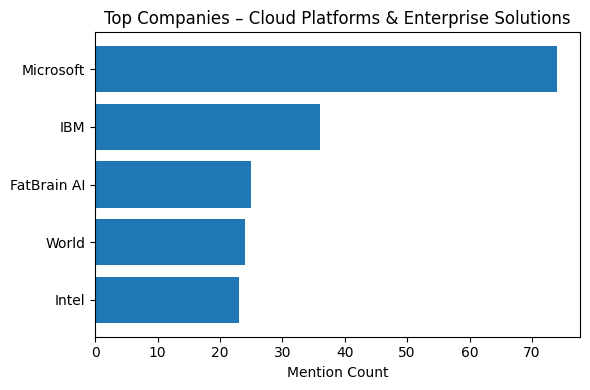

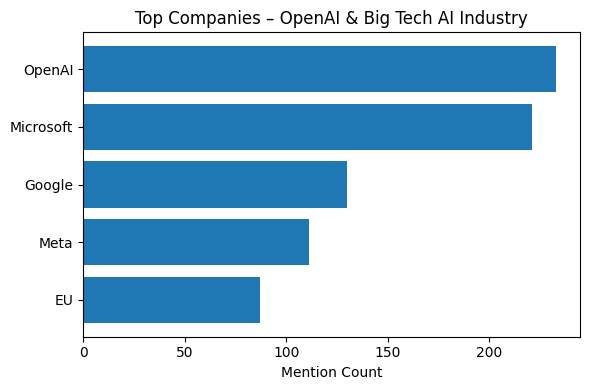

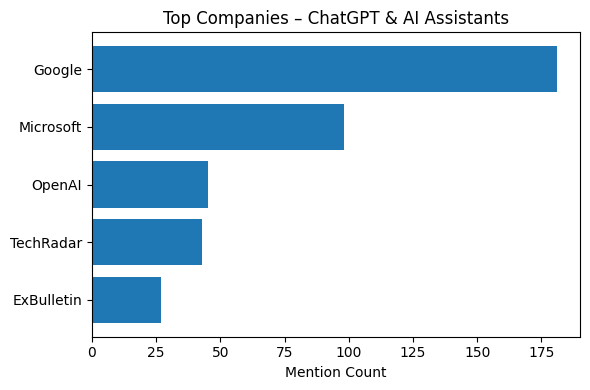

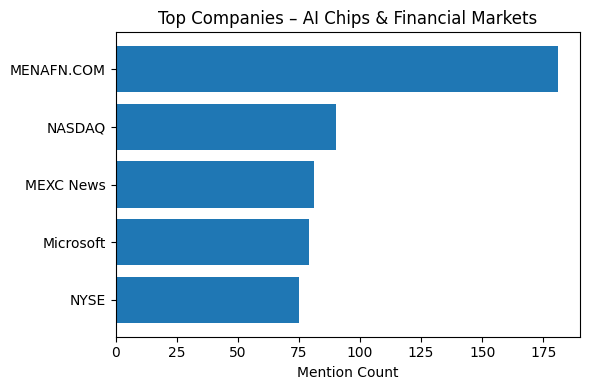

In [17]:
# Remove non-company terms like "AI"
bad_companies = {"ai", "artificial intelligence", "Exbulletin", "EU"}

company_table = company_table[
    ~company_table["company"].str.lower().isin(bad_companies)
].copy()

top_industries = plot_df.head(4)["topic_id"].tolist()

for t in top_industries:
    subset = company_table[company_table["topic_id"] == t].head(5)

    plt.figure(figsize=(6,4))
    plt.barh(subset["company"], subset["mention_count"])
    plt.title(f"Top Companies – {topic_labels[t]}")
    plt.xlabel("Mention Count")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [24]:
BAD_COMPANIES = {
    "ai",
    "artificial intelligence",
    "menafn.com",
    "mexC news",
    "techradar",
    "exbulletin",
    "eu",
    "world",
    "news",
    "media",
    "press"
}

company_table_clean = company_table[
    ~company_table["company"].str.lower().isin(BAD_COMPANIES)
].copy()

MEDIA_ORGS = {
    "nbc", "techradar", "exbulletin",
    "menafn", "menafn.com", "mexc news",
    "cnn", "bbc", "reuters", "bloomberg"
}

company_table_clean = company_table[
    ~company_table["company"].str.lower().isin(MEDIA_ORGS)
].copy()

BAD_ENTITIES = {
    "ai", "artificial intelligence",
    "chatgpt", "gpt",

    # media
    "canindia news", "techradar", "exbulletin", "menafn", "menafn.com",
    "mexc news", "nbc", "cnn", "bbc", "reuters",

    # institutions
    "eu", "european union",

    # generic words
    "world"
}

company_table_clean = company_table[
    ~company_table["company"].str.lower().isin(BAD_ENTITIES)
].copy()

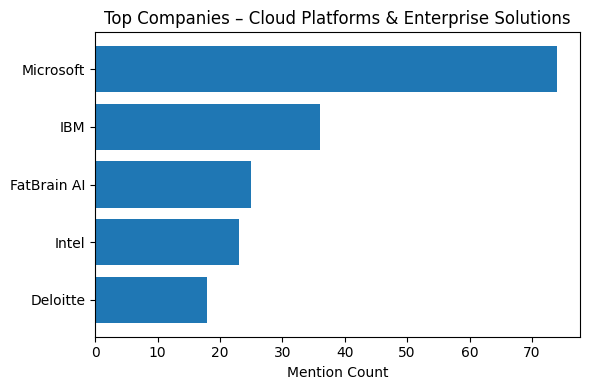

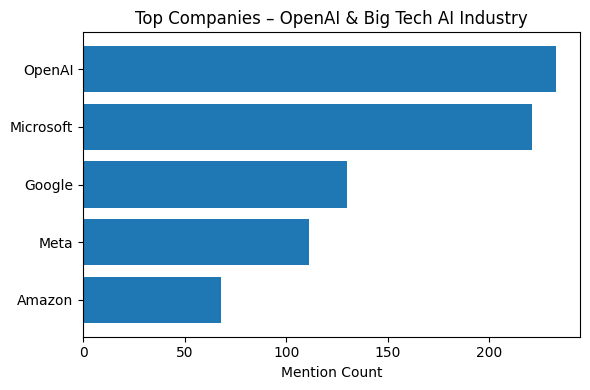

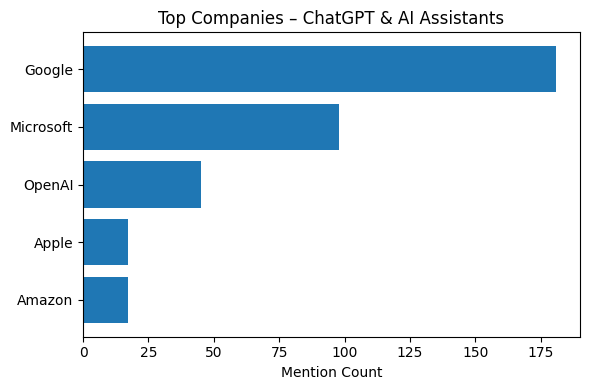

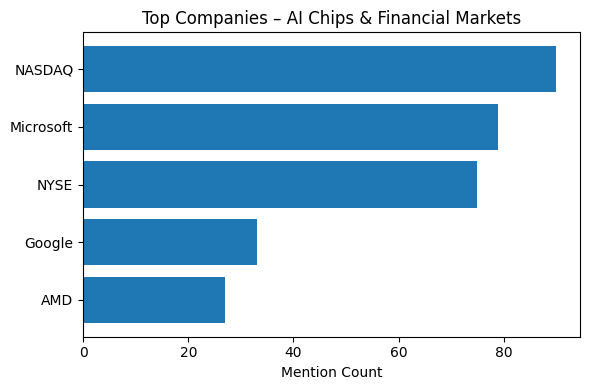

In [26]:
top_industries = plot_df.head(4)["topic_id"].tolist()

for t in top_industries:
    subset = (
        company_table_clean[company_table_clean["topic_id"] == t]
        .sort_values("mention_count", ascending=False)
        .head(5)
    )

    plt.figure(figsize=(6,4))
    plt.barh(subset["company"], subset["mention_count"])
    plt.title(f"Top Companies – {topic_labels[t]}")
    plt.xlabel("Mention Count")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

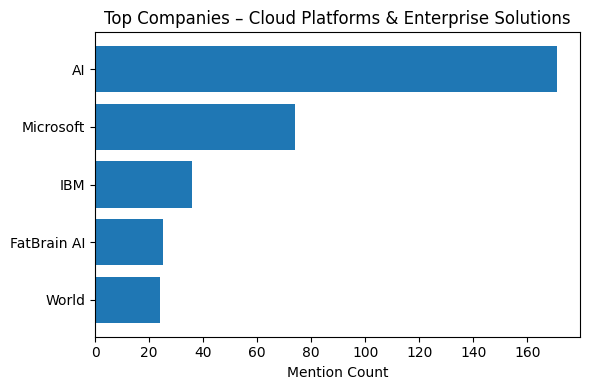

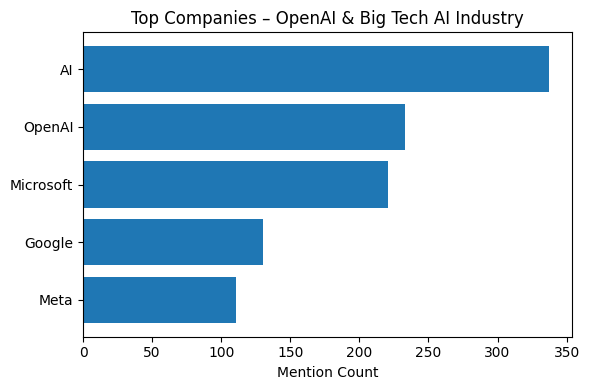

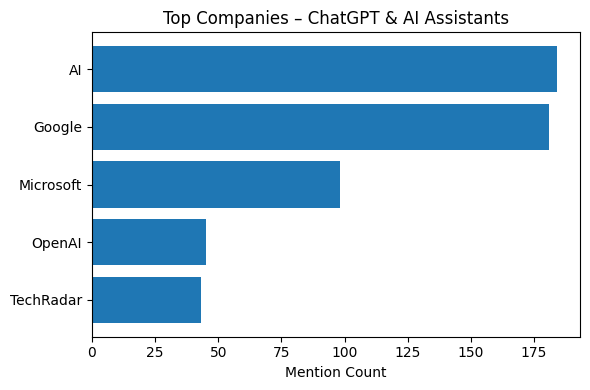

In [ ]:
top_industries = plot_df.head(3)["topic_id"].tolist()

for t in top_industries:
    subset = company_table[company_table["topic_id"] == t].head(5)

    plt.figure(figsize=(6,4))
    plt.barh(subset["company"], subset["mention_count"])
    plt.title(f"Top Companies – {topic_labels[t]}")
    plt.xlabel("Mention Count")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

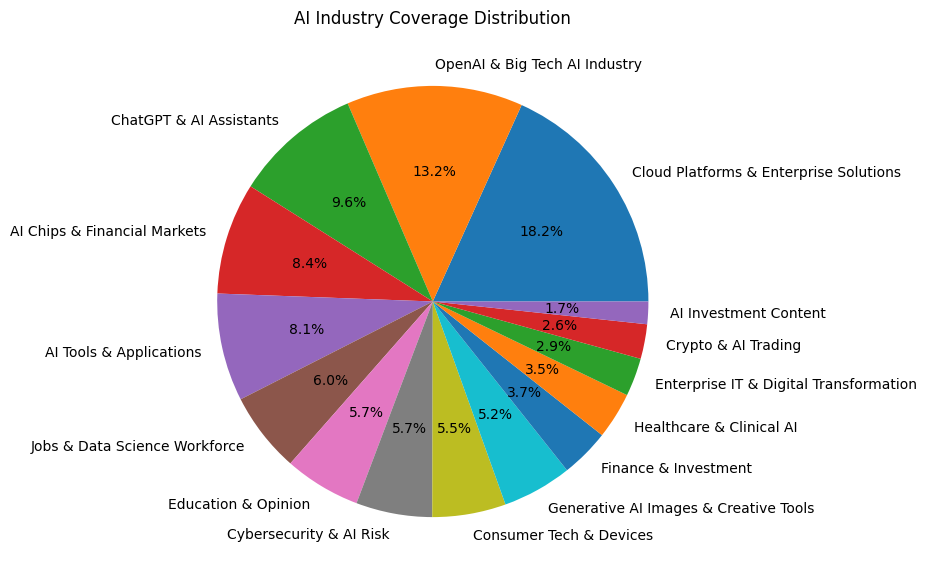

In [ ]:
plt.figure(figsize=(7,7))
plt.pie(plot_df["doc_share"], labels=plot_df["label"], autopct="%1.1f%%")
plt.title("AI Industry Coverage Distribution")
plt.show()

In [ ]:
industry_summary = lda_table[~lda_table["topic_id"].isin({1,2,7,12,18})][
    ["topic_id","label","doc_count","doc_share"]
].sort_values("doc_share", ascending=False)

industry_summary

,topic_id,label,doc_count,doc_share
13,13,Cloud Platforms & Enterprise Solutions,5452,0.1363
17,17,OpenAI & Big Tech AI Industry,3951,0.0988
16,16,ChatGPT & AI Assistants,2860,0.0715
3,3,AI Chips & Financial Markets,2505,0.0626
4,4,AI Tools & Applications,2416,0.0604
8,8,Jobs & Data Science Workforce,1801,0.0450
10,10,Education & Opinion,1713,0.0428
19,19,Cybersecurity & AI Risk,1707,0.0427
11,11,Consumer Tech & Devices,1648,0.0412
14,14,Generative AI Images & Creative Tools,1558,0.0390


In [ ]:
bad_orgs = {"AI", "Artificial Intelligence", "AI Software", "Healthcare", "Google AI"}

company_table_clean = company_table[~company_table["company"].isin(bad_orgs)]

top5_companies = (
    company_table_clean
    .groupby(["topic_id","label"])
    .head(5)
    .reset_index(drop=True)
)

top5_companies

,topic_id,label,company,mention_count
0,0,Healthcare & Clinical AI,SafetyLit,25
1,0,Healthcare & Clinical AI,Eureka Clinical AI Platform,13
2,0,Healthcare & Clinical AI,TeraRecon,10
3,0,Healthcare & Clinical AI,ScienceDaily,8
4,0,Healthcare & Clinical AI,ExBulletin,8
...,...,...,...,...
70,19,Cybersecurity & AI Risk,Computer Weekly,46
71,19,Cybersecurity & AI Risk,VentureBeat,36
72,19,Cybersecurity & AI Risk,CIO News,26
73,19,Cybersecurity & AI Risk,Microsoft,26
